In [3]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data = pd.read_csv('u.data', sep='\t', names=['user_id','item_id','rating','timestamp'])

In [5]:
item_user_matrix = data.pivot(index='item_id', columns='user_id', values='rating')
item_user_matrix.fillna(0, inplace=True)

In [6]:
item_similarity = cosine_similarity(item_user_matrix)
item_similarity_df = pd.DataFrame(item_similarity)

In [7]:
similar_items = item_similarity_df[0].sort_values(ascending=False)[1:6]
similar_items

,0
49,0.734572
180,0.699925
120,0.689786
116,0.664555
404,0.641322


In [8]:
item_id = 1
recommended_items = item_similarity_df[item_id].sort_values(ascending=False)[1:10]
recommended_items

,1
232,0.659619
160,0.623544
384,0.617274
402,0.616143
61,0.604969
575,0.601960
225,0.597083
230,0.595684
549,0.590124


In [12]:
predicted_ratings = np.dot(item_similarity, item_user_matrix) / np.array([np.abs(item_similarity).sum(axis=1)]).T

In [13]:
rmse = np.sqrt(mean_squared_error(item_user_matrix.values.flatten(), predicted_ratings.flatten()))
print("RMSE:", rmse)

RMSE: 0.8449294250334455


In [14]:
def precision_at_k(recommended, relevant, k):
    return len(set(recommended[:k]) & set(relevant)) / k

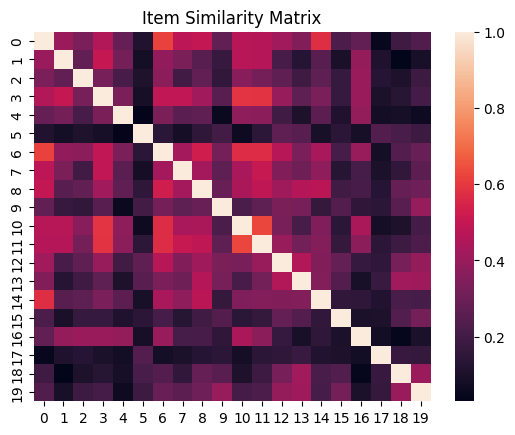

In [15]:
sns.heatmap(item_similarity_df.iloc[:20,:20])
plt.title("Item Similarity Matrix")
plt.show()